# Synthetic Manifold Data in Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 


### Helper Functions

In [2]:
def _beta_lin(n, a=1.0, b=1.0, lo=0.0, hi=1.0, rng=None):
    rng = np.random.default_rng(rng)
    t = rng.beta(a, b, n)
    return lo + (hi - lo) * t

def add_ambient_noise(X, sigma=0.0, rng=None):
    if sigma <= 0: 
        return X
    rng = np.random.default_rng(rng)
    return X + rng.normal(0, sigma, X.shape)


### Swiss roll

In [3]:
def swiss_roll(n=2000, height=10.0, turns=3.0, hole=False, hole_center=(8.0, 5.0), 
               hole_radius=2.0, density=('beta',2,5), noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    if density == 'uniform':
        t = rng.uniform(0, 2*np.pi*turns, n)
    else:
        _, a, b = density
        t = _beta_lin(n, a, b, lo=0, hi=2*np.pi*turns, rng=rng)
    y = rng.uniform(0, height, n)
    x = t * np.cos(t)
    z = t * np.sin(t)
    X = np.vstack([x, y, z]).T
    if hole:
        mask = ( (X[:,0]-hole_center[0])**2 + (X[:,2]-hole_center[1])**2 ) > hole_radius**2
        X = X[mask]
    X = add_ambient_noise(X, noise, rng)
    return X, dict(name='swiss_roll', n=len(X), height=height, turns=turns, hole=hole)

X, meta = swiss_roll(n=3000, height=10.0, turns=3.0, hole=True, hole_center=(8.0,5.0), hole_radius=2.0, noise=0.01, rng=0)

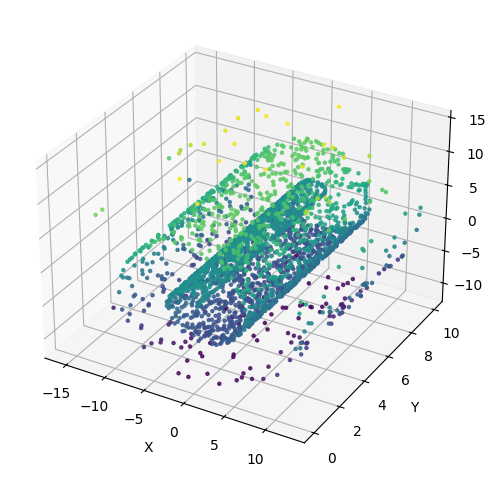

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### $S$-curve

In [5]:

def s_curve(n=2000, width=2.0, height=4.0, density=('beta',2,5), noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    if density == 'uniform':
        t = rng.uniform(0, 1, n)
    else:
        _, a, b = density
        t = _beta_lin(n, a, b, rng=rng)
    t = (t - 0.5) * np.pi * 1.5
    x = np.sin(t)
    z = np.sign(t)*(1 - np.cos(t))
    y = rng.uniform(0, height, n) - height/2
    X = np.vstack([width*x, y, width*z]).T
    X = add_ambient_noise(X, noise, rng)
    return X, dict(name='s_curve', n=n)

X, meta = s_curve(n=3000, width=4.0, height=10.0, noise=0.01, rng=0)

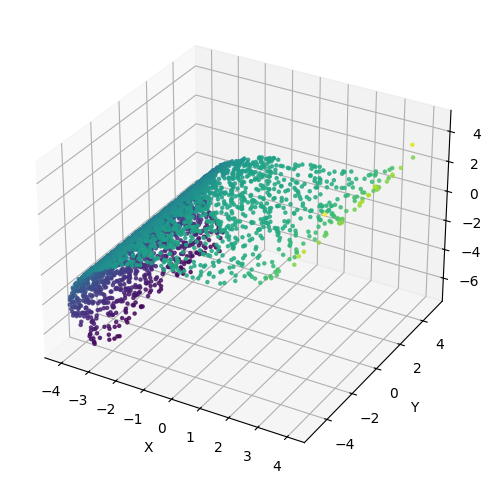

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Torus

In [7]:
def torus(n=4000, R=3.0, r=1.0, noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    u = rng.uniform(0, 2*np.pi, n)
    v = rng.uniform(0, 2*np.pi, n)
    x = (R + r*np.cos(v))*np.cos(u)
    y = (R + r*np.cos(v))*np.sin(u)
    z = r*np.sin(v)
    X = np.vstack([x, y, z]).T
    X = add_ambient_noise(X, noise, rng)
    return X, dict(name='torus', n=n, R=R, r=r)

X, meta = torus(n=3000, R=3.0, r=1.0, noise=0.01, rng=0)

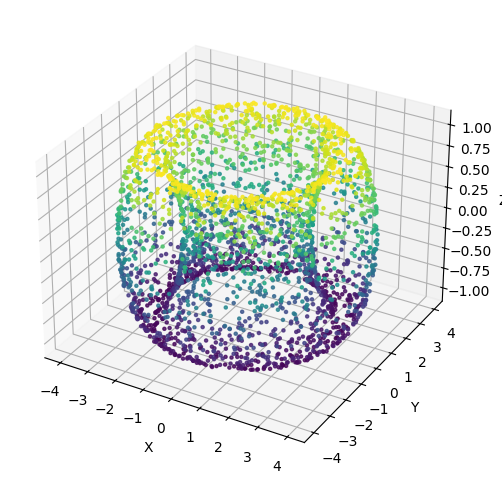

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Mobius strip

In [9]:
def mobius(n=4000, w=0.3, noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    u = rng.uniform(0, 2*np.pi, n)
    v = rng.uniform(-w, w, n)
    x = (1 + v*np.cos(u/2))*np.cos(u)
    y = (1 + v*np.cos(u/2))*np.sin(u)
    z = v*np.sin(u/2)
    X = np.vstack([x, y, z]).T
    X = add_ambient_noise(X, noise, rng)
    return X, dict(name='mobius', n=n, w=w)

X, meta = mobius(n=3000, w=0.3, noise=0.01, rng=0)

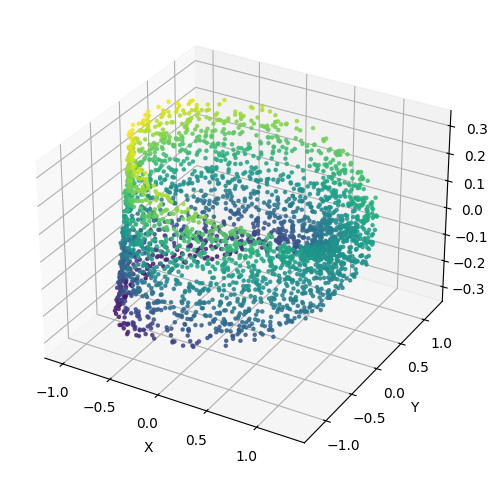

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Swiss with bridges

In [11]:
def swiss_with_bridges(n=2500, n_bridges=15, bridge_spread=0.3, noise=0.0, rng=None):
    X, meta = swiss_roll(n=n, height=8.0, turns=3.0, noise=noise, rng=rng)
    rng = np.random.default_rng(rng)
    # pick random distant pairs in parameter space by shuffling indices
    idx = rng.choice(len(X), size=2*n_bridges, replace=False)
    pairs = idx.reshape(-1, 2)
    bridges = []
    for i, j in pairs:
        t = rng.uniform(0, 1, 20)
        B = (1-t)[:,None]*X[i] + t[:,None]*X[j]
        B += rng.normal(0, bridge_spread, B.shape)
        bridges.append(B)
    if bridges:
        X = np.vstack([X] + bridges)
    meta['bridges'] = n_bridges
    return X, meta

X, meta = swiss_with_bridges(n=4000, n_bridges=300, bridge_spread=0.2, noise=0.05, rng=0)

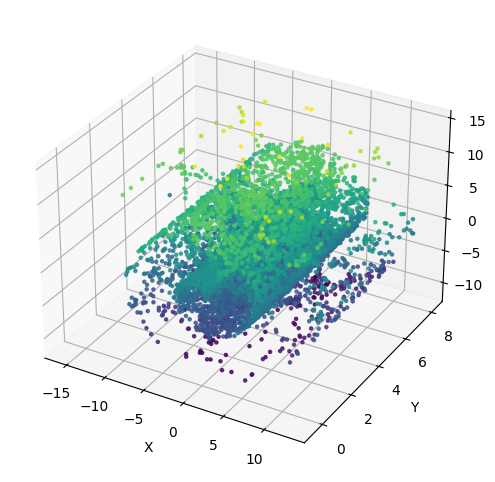

In [12]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Curve plus sheet

A one-dimensional helix curve combined with a two-dimensional (sinusoidal) sheet.

In [13]:
def curve_plus_sheet(n_curve=1500, n_sheet=2500, sheet_size=1.5, noise=0.01, rng=None):
    rng = np.random.default_rng(rng)
    # 1D curve (helix segment)
    t = rng.uniform(0, 2*np.pi, n_curve)
    xc = np.cos(t); yc = np.sin(t); zc = t/(2*np.pi)
    C = np.vstack([xc, yc, zc]).T
    # 2D sheet (warped square)
    u = rng.uniform(-1, 1, n_sheet); v = rng.uniform(-1, 1, n_sheet)
    xs = u; ys = v; zs = 0.2*np.sin(np.pi*u*v)
    S = sheet_size*np.vstack([xs, ys, zs]).T + np.array([2.5, 0, 0])  # offset
    X = np.vstack([C, S])
    X = add_ambient_noise(X, noise, rng)
    labels = np.r_[np.zeros(n_curve, dtype=int), np.ones(n_sheet, dtype=int)]  # 0=curve,1=sheet
    return (X, dict(name='curve_plus_sheet', n=len(X), sheet_size=sheet_size, labels=labels))

X, meta = curve_plus_sheet(n_curve=1500, n_sheet=2500, sheet_size=1.5, noise=0.01, rng=0)


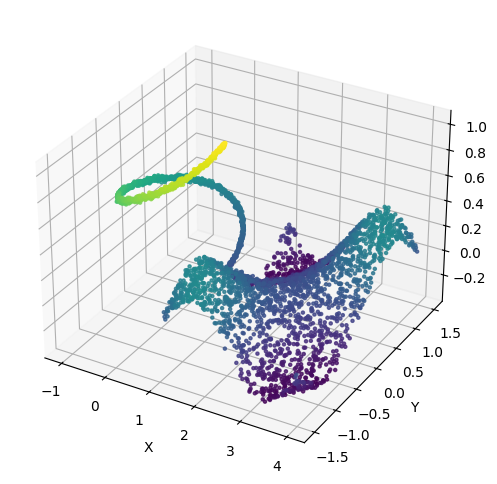

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Branched Curve

Two one-dimensional curves that branch off from a common trunk.

In [15]:
def branched_curve(n=3000, branch_prob=(0.4, 0.3, 0.3), noise=0.01, rng=None):
    rng = np.random.default_rng(rng)
    ps = np.array(branch_prob)/np.sum(branch_prob)
    labels = rng.choice(3, size=n, p=ps)
    t = rng.uniform(0, 1, n)
    X = np.zeros((n, 3))

    mask0 = labels==0
    X[mask0] = np.stack([np.zeros(mask0.sum()), 
                         0.1*np.sin(6*np.pi*t[mask0]), 
                         2*t[mask0]], axis=1)
    # branch 1: rotate and bend
    mask1 = labels==1
    X[mask1] = np.stack([t[mask1], 0.2*t[mask1]**2, 2*(0.5+t[mask1]/2)], axis=1)
    # branch 2: different orientation
    mask2 = labels==2
    X[mask2] = np.stack([-t[mask2], -0.2*t[mask2]**2, 2*(0.5+t[mask2]/2)], axis=1)
    X = add_ambient_noise(X, noise, rng)
    return X, dict(name='branched_curve', n=n, ps=ps)

X, meta = branched_curve(n=3000, branch_prob=(0.4, 0.3, 0.3), noise=0.01, rng=0)

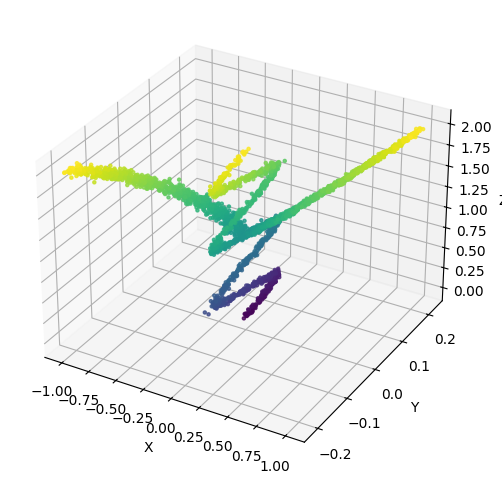

In [16]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=X[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Diffemorphic Transform

Apply to any manifold data to create a more complex embedding.

In [17]:
def smooth_warp(X, a=0.3):
    # sinusoidal diffeomorphism
    x, y, z = X[:,0], X[:,1], X[:,2]
    Xw = np.column_stack([
        x + a*np.sin(y),
        y + a*np.sin(z),
        z + a*np.sin(x)
    ])
    return Xw

# example usage
X, meta = torus(n=3000, R=3.0, r=1.0, noise=0.01, rng=0)
Xw = smooth_warp(X, a=0.3)


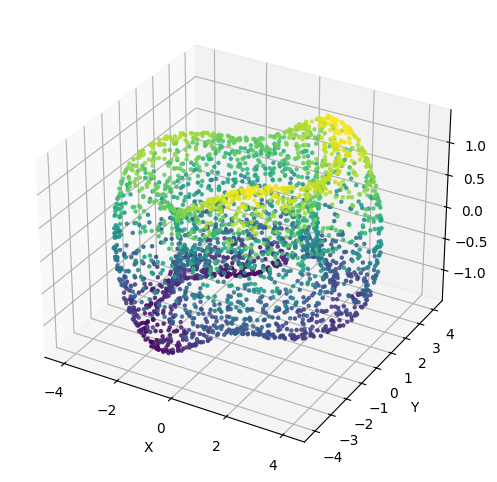

In [18]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Xw[:, 0], Xw[:, 1], Xw[:, 2],
           c=Xw[:, 2],  
           cmap='viridis',
           s=5, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


### Nuisance Dimensions

Make the data higher-dimensional by adding ambient noise dimensions.

In [19]:
import numpy as np

def add_nuisance_dims(X, nuisance_dim=5, noise_scale=0.1, rng=None):
    rng = np.random.default_rng(rng)
    n_samples = X.shape[0]
    nuisance = rng.normal(0, noise_scale, size=(n_samples, nuisance_dim))
    return np.hstack([X, nuisance])


# example usage
X, meta = torus(n=3000, R=3.0, r=1.0, noise=0.01, rng=0)
Xw = add_nuisance_dims(X, nuisance_dim=5, noise_scale=0.1, rng=0) #added 5 dimensions

print(f"Shape of original data: {X.shape} \nShape of data with added nuisance dimensions: {Xw.shape}")

Shape of original data: (3000, 3) 
Shape of data with added nuisance dimensions: (3000, 8)
